# Séries Temporelles : fiche TP3
Thomas Besnier, Wilfried Heyse


## Estimation paramétrique de la tendance

1. Représenter graphiquement la série. Ce processus vous semble-t-il stationnaire ? Présente-t-il des tendances et saisonnalités ?

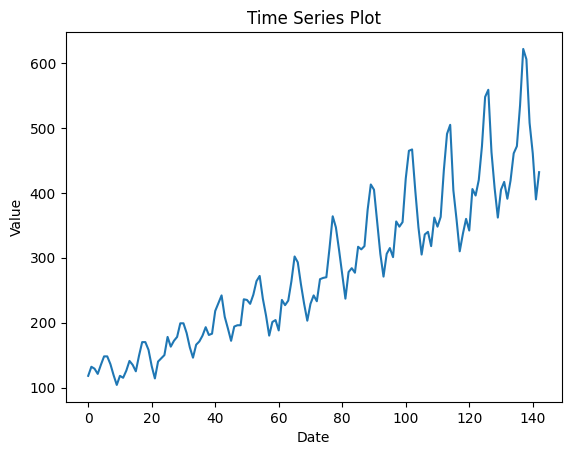

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read data from text file
with open("AirPassengers.txt", "r") as file:
    lines = file.readlines()

data = []
for line in lines[1:]:
    values = line.strip().split()
    data.extend([float(value) for value in values])

serie = pd.Series(data)
plt.plot(serie)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Time Series Plot')
plt.show()

2. Estimer les paramètres d’une tendance linéaire at + b.

In [4]:
time = np.arange(0, len(data))

In [5]:
import statsmodels.api as sm  # Linear regression

X = sm.add_constant(time)  # Add constant
model = sm.OLS(data, X).fit()

In [6]:
model.params

array([92.36043124,  2.66359286])

In [7]:
tendance = model.params[1] * time + model.params[0]

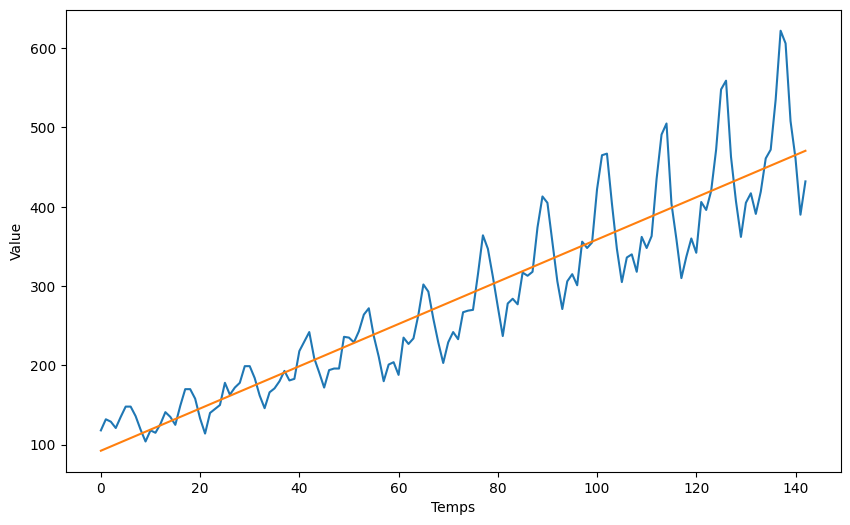

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(data)
plt.plot(tendance)
plt.xlabel('Temps')
plt.ylabel('Value')
plt.show()

3. Supprimer cette tendance et représenter graphiquement la série ainsi obtenue. Vérifier que la série des résidus est de moyenne nulle.

In [9]:
residus = data - tendance

In [10]:
print(np.mean(np.array(residus)))

8.138944064161148e-14


4. Calculer et représenter l’auto-corrélation de la série des résidus.

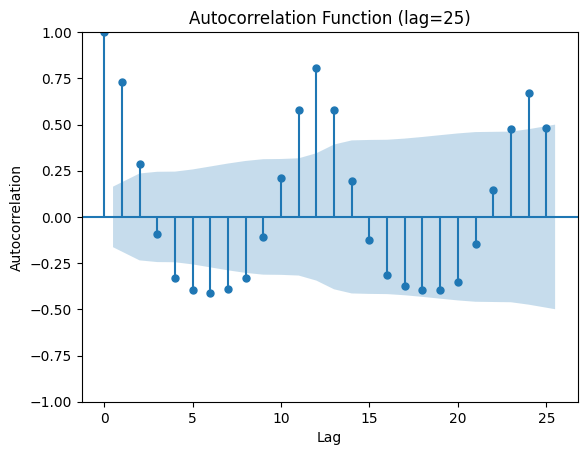

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residus, lags=25, title='Autocorrelation Function (lag=25)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

## Méthode des différences

1. Appliquer la méthode des différences pour enlever la tendance et la saisonnalité. Préciser la période de la saisonnalité, le degré du polynôme de tendance.

In [12]:
data = {
    'temps': time,
    'serie': data 
}
data_serie = pd.DataFrame(data)

# Define the period (lag)
periode = 12

# first difference with specified lag
x1 = data_serie['serie'].diff(periods=periode).dropna()

# Compute the mean of the differences
mean_x1 = x1.mean()

print("Mean of the first differences with lag", periode, ":", mean_x1)

Mean of the first differences with lag 12 : 31.99236641221374


In [13]:
# second difference using the first difference
x2 = x1.diff(periods=periode).dropna()

# mean of the second differences
mean_x2 = x2.mean()

print("Mean of the second differences with lag", periode, ":", mean_x2)

Mean of the second differences with lag 12 : 3.2857142857142856


In [14]:
# third difference using the second difference
x3 = x2.diff(periods=periode).dropna()

# mean of third differences
mean_x3 = x3.mean()

print("Mean of the second differences with lag", periode, ":", mean_x3)

Mean of the second differences with lag 12 : -1.6168224299065421


2. La série obtenue semble-t-elle stationnaire ?

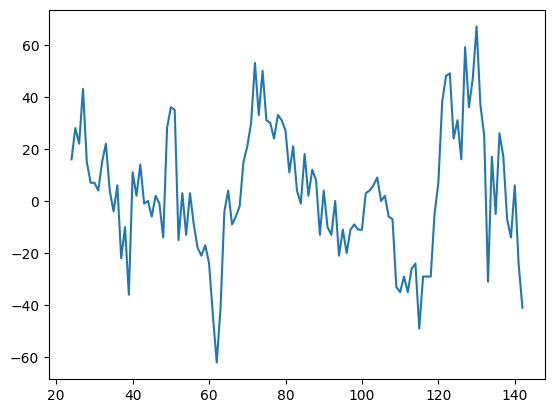

In [16]:
plt.plot(x2)
plt.show()

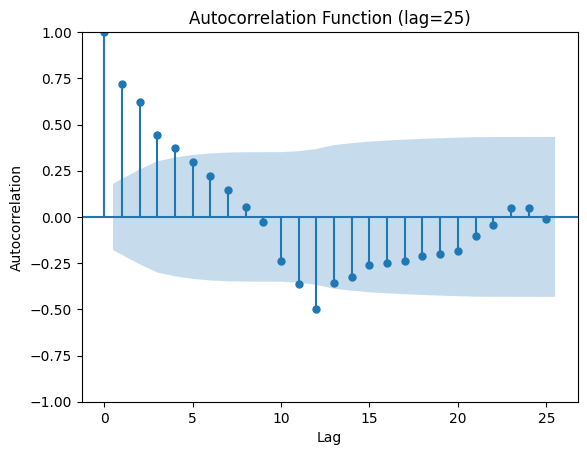

In [17]:
plot_acf(x2, lags=25, title='Autocorrelation Function (lag=25)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

## Méthode des moyennes mobiles

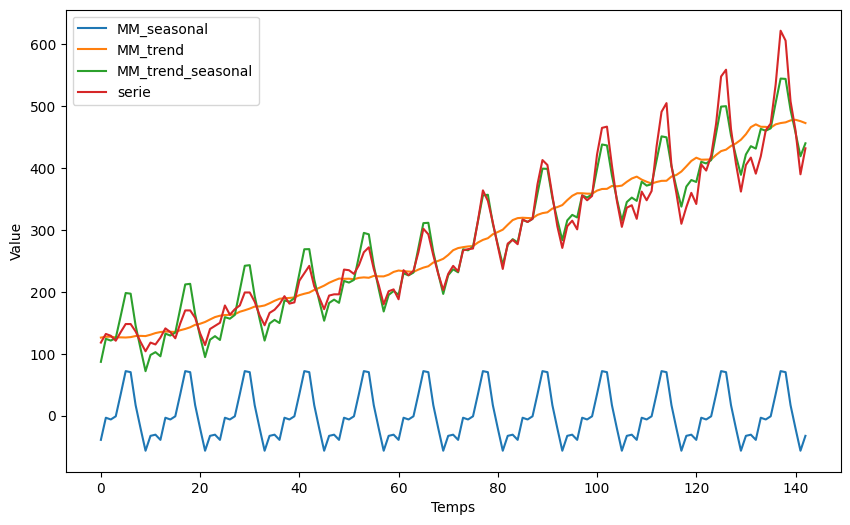

In [18]:
periode = 12

# moving average trend
MM_trend = []
for i in range(len(data_serie)):
    fenetre = list(range(i - round(periode / 2), i + round(periode / 2) + 1))
    if i < periode:
        fenetre = [x if x >= 0 else 0 for x in fenetre]
    elif i > (len(data_serie) - periode):
        fenetre = [x if x < len(data_serie) else len(data_serie) - 1 for x in fenetre]
    MM_trend.append(data_serie['serie'][fenetre].mean())

data_serie['MM_trend'] = MM_trend

# seasonal component
MM_seasonal = []
for i in range(periode):
    indices = list(range(i, len(data_serie), periode))
    MM_seasonal.append((data_serie['serie'][indices] - data_serie['MM_trend'][indices]).mean())

data_serie['MM_seasonal'] = np.tile(MM_seasonal, len(data_serie) // periode + 1)[:len(data_serie)]
data_serie['MM_trend_seasonal'] = data_serie['MM_trend'] + data_serie['MM_seasonal']

# Melt dataframe for plotting
data_serie_melted = pd.melt(data_serie, id_vars=['temps'], value_vars=['serie', 'MM_trend', 'MM_seasonal', 'MM_trend_seasonal'],
                            var_name='name', value_name='value')

plt.figure(figsize=(10, 6))
for label, df in data_serie_melted.groupby('name'):
    plt.plot(df['temps'], df['value'], label=label)
plt.xlabel('Temps')
plt.ylabel('Value')
plt.legend()
plt.show()

In [23]:
residus = serie - data_serie['MM_trend_seasonal']

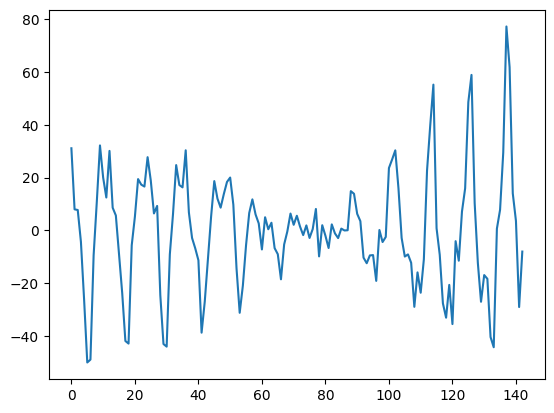

In [25]:
plt.plot(residus)
plt.show()

2. La série obtenue semble-t-elle stationnaire ? Pourquoi ?

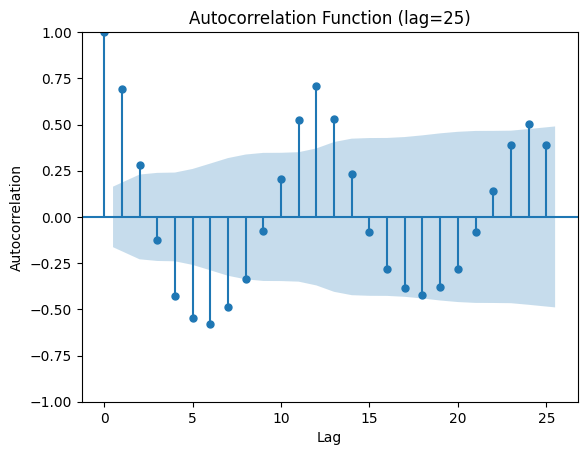

In [28]:
plot_acf(residus, lags=25, title='Autocorrelation Function (lag=25)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

Processus non stationnaire, modèle inadapté (potentiellement multiplicatif)